# **AIN 214 - PA3 - FALL 2025**

**Student Number** : 2230765032

**Name Surname**   : Baki Umut Gündüz


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 15.12.2025 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>

# **Data Prepocessing and Regression**

---
**Dataset Path:** "Data/diamonds.csv"
---

We will deal with the diamonds dataset. The Diamonds dataset contains physical measurements and quality grades for approximately 54,000 round-cut diamonds, used to predict diamond prices based on characteristics such as carat weight, cut quality, color grade, clarity, and dimensions.

**Features:**

* Cut: The quality of the diamond's cut, which affects how well it reflects light; Ideal is the best cut quality.
* Color: The diamond's color grade, where D is completely colorless (best) and J has noticeable yellow tint (worst).
* Clarity: The clarity grade measuring internal flaws (inclusions); IF (Internally Flawless) is best, I1 (Included) is worst.
* Carat: The weight of the diamond; 1 carat = 0.2 grams (ranges from 0.2 to 5.01 carats).
* Depth: The total depth percentage, calculated as z / mean(x, y), representing the height from culet to table divided by average diameter (ranges from 43% to 79%).
* Table: The width of the diamond's top facet (table) relative to its widest point (ranges from 43% to 95%).
* x: The length of the diamond in millimeters (ranges from 0 to 10.74 mm).
* y: The width of the diamond in millimeters (ranges from 0 to 58.9 mm).
* z: The depth/height of the diamond in millimeters (ranges from 0 to 31.8 mm).
* Price: The price of the diamond in US dollars, ranging from \$326 to \$18,823.






# **Necessary Imports**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **PART- 1: Data Preprocessing (50 Pts)**

---

## 1.1. Explaratory Data Analysis (10 Pts)

* Check for missing values (if any)
* Visualize the target variable with respect to the features
* Visualize the correlation between the features using a heatmap
* Comment on any findings

Missing Values in Data:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64
------------------------------


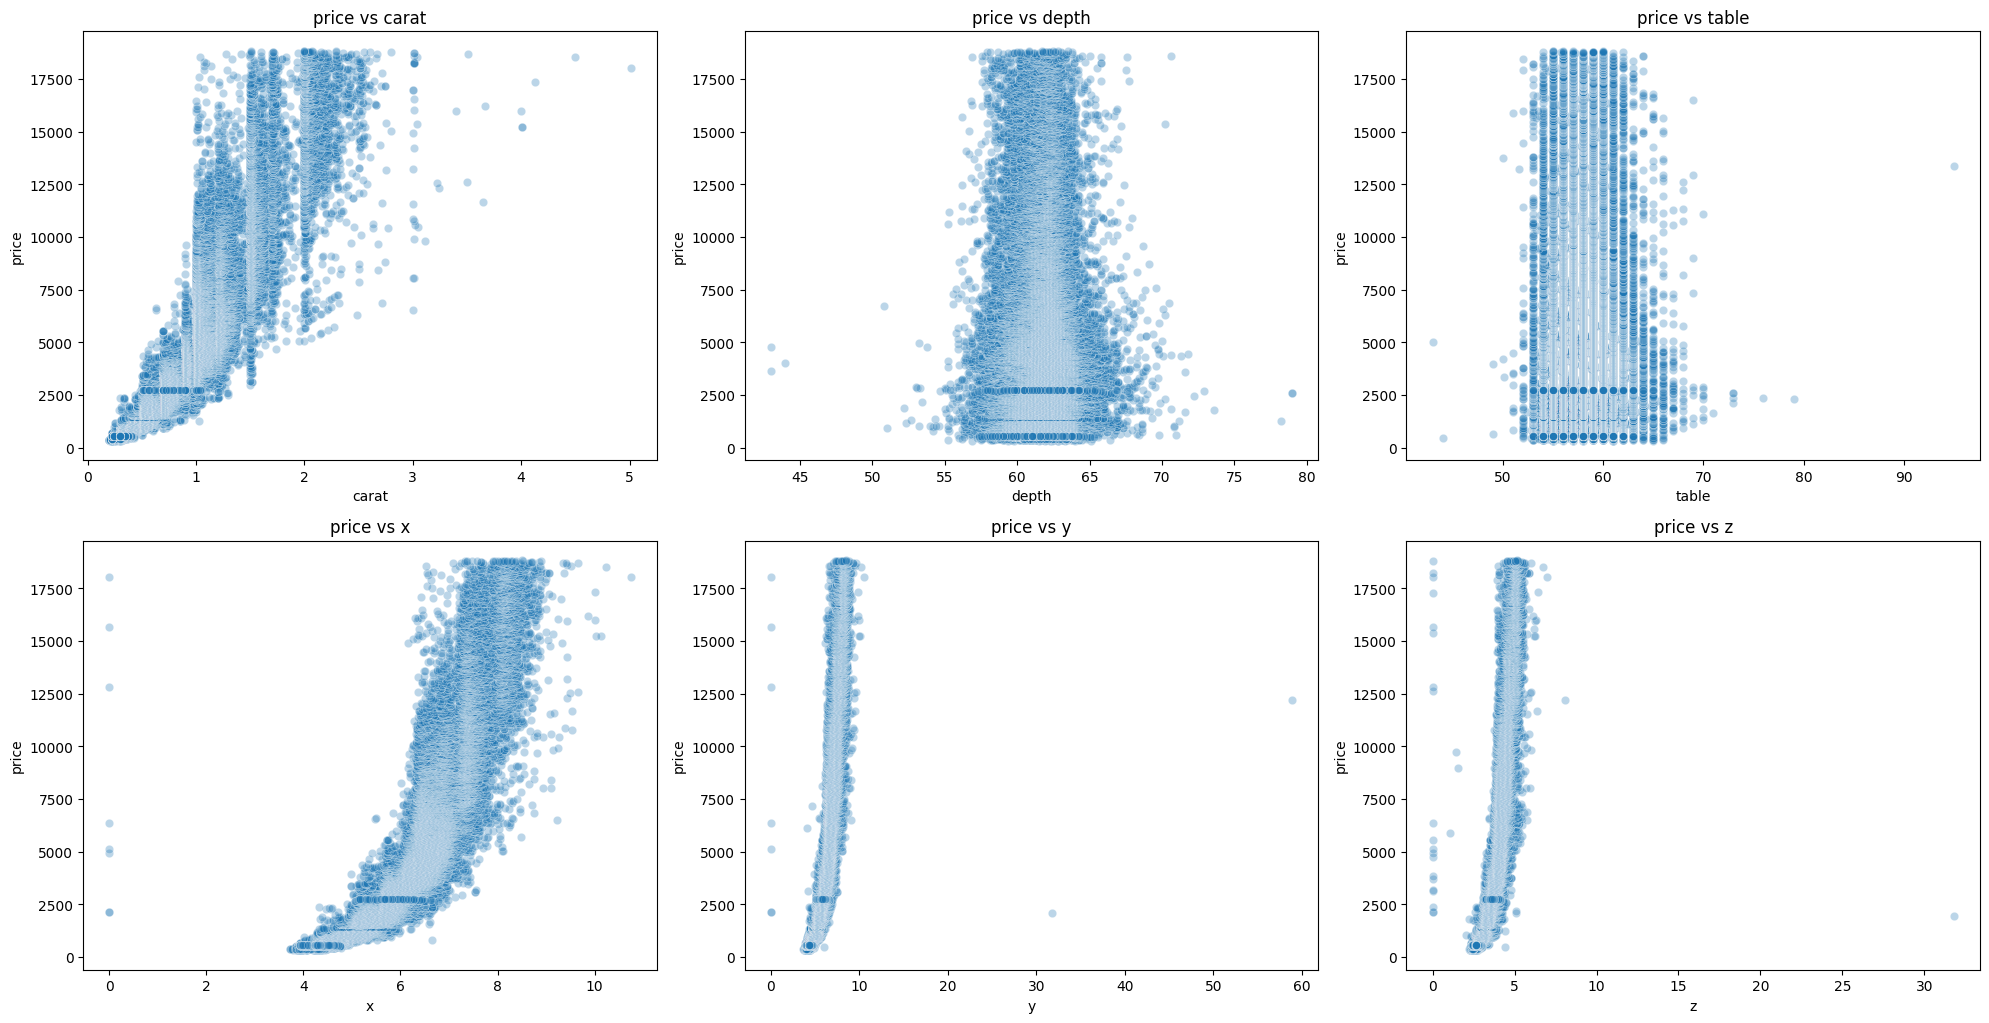

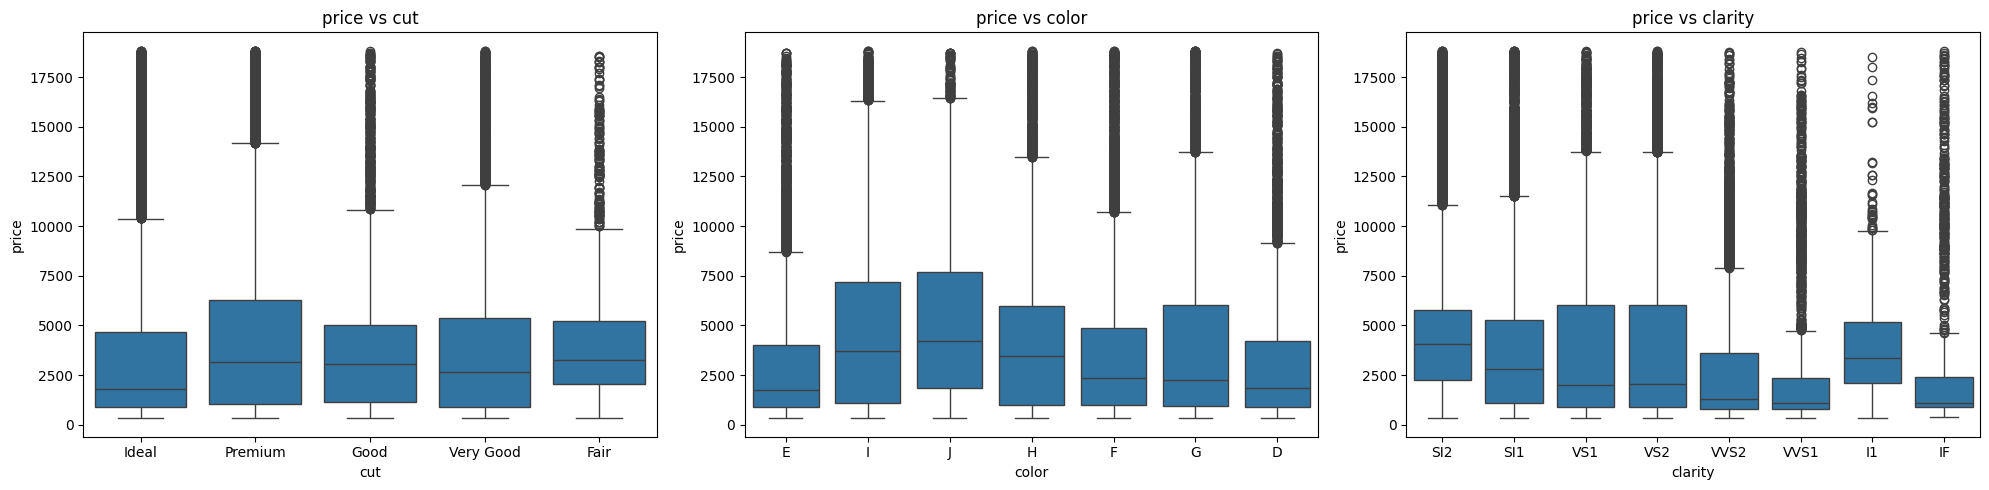

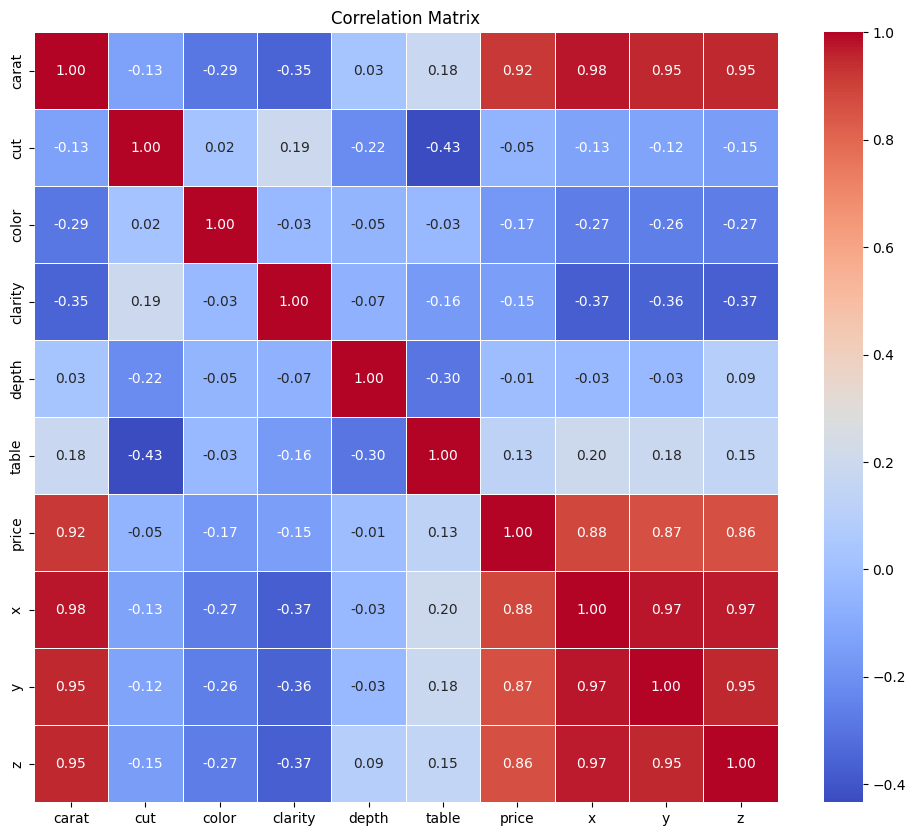

In [2]:
# implementation here
df_original = pd.read_csv("Data/diamonds.csv")

print("Missing Values in Data:")
print(df_original.isnull().sum())
print("-" * 30)

if 'Unnamed: 0' in df_original.columns:
    df_original = df_original.drop('Unnamed: 0', axis=1)

target = 'price'
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(data=df_original, x=feature, y=target, alpha=0.3)
    plt.title(f'{target} vs {feature}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 5))
for i, feature in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df_original, x=feature, y=target)
    plt.title(f'{target} vs {feature}')
plt.tight_layout()
plt.show()

df_heatmap = df_original.copy()

cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
df_heatmap['cut'] = df_heatmap['cut'].map(cut_map)

color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
df_heatmap['color'] = df_heatmap['color'].map(color_map)

clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}
df_heatmap['clarity'] = df_heatmap['clarity'].map(clarity_map)

corr_matrix = df_heatmap.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


I checked the dataset and found no missing values. There is a strong positive correlation between price and carat. Also, the dimensions (x, y, z) are highly correlated with the price. Categorical features like color and clarity also seem to affect the price significantly.

## 1.2. Outlier Detection (15 Pts)
* Choose an outlier detection method and apply it to the data.
* Explain your method and why you choose it.

In [3]:
# implementation here
Q1 = df_original[numeric_features].quantile(0.25)
Q3 = df_original[numeric_features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df_original[numeric_features] < lower_bound) | (df_original[numeric_features] > upper_bound)).sum()

print("--- Column by Outliers ---")
print(outliers_count)

print("\n--- Total Number of Outliers ---")
total_outliers = ((df_original[numeric_features] < lower_bound) | (df_original[numeric_features] > upper_bound)).any(axis=1).sum()
print(total_outliers)


--- Column by Outliers ---
carat    1889
depth    2545
table     605
x          32
y          29
z          49
dtype: int64

--- Total Number of Outliers ---
4636


I chose the IQR (Interquartile Range) method because it is robust and effective for detecting outliers without assuming a normal distribution. Since variables like price and carat often have skewed distributions, the IQR method works better than the Z-score method. It focuses on the middle 50% of the data, making it less sensitive to extreme values.

## 1.3. Outlier Handling (15 Pts)
Using the selected method, remove the outliers and keep the original dataset as a checkpoint for comparison. After removing the outliers, visualize the updated dataset to show the changes.

Original Data Count    : 53940
Cleaned Data Count     : 49304
Removed Outliers Count : 4636
------------------------------


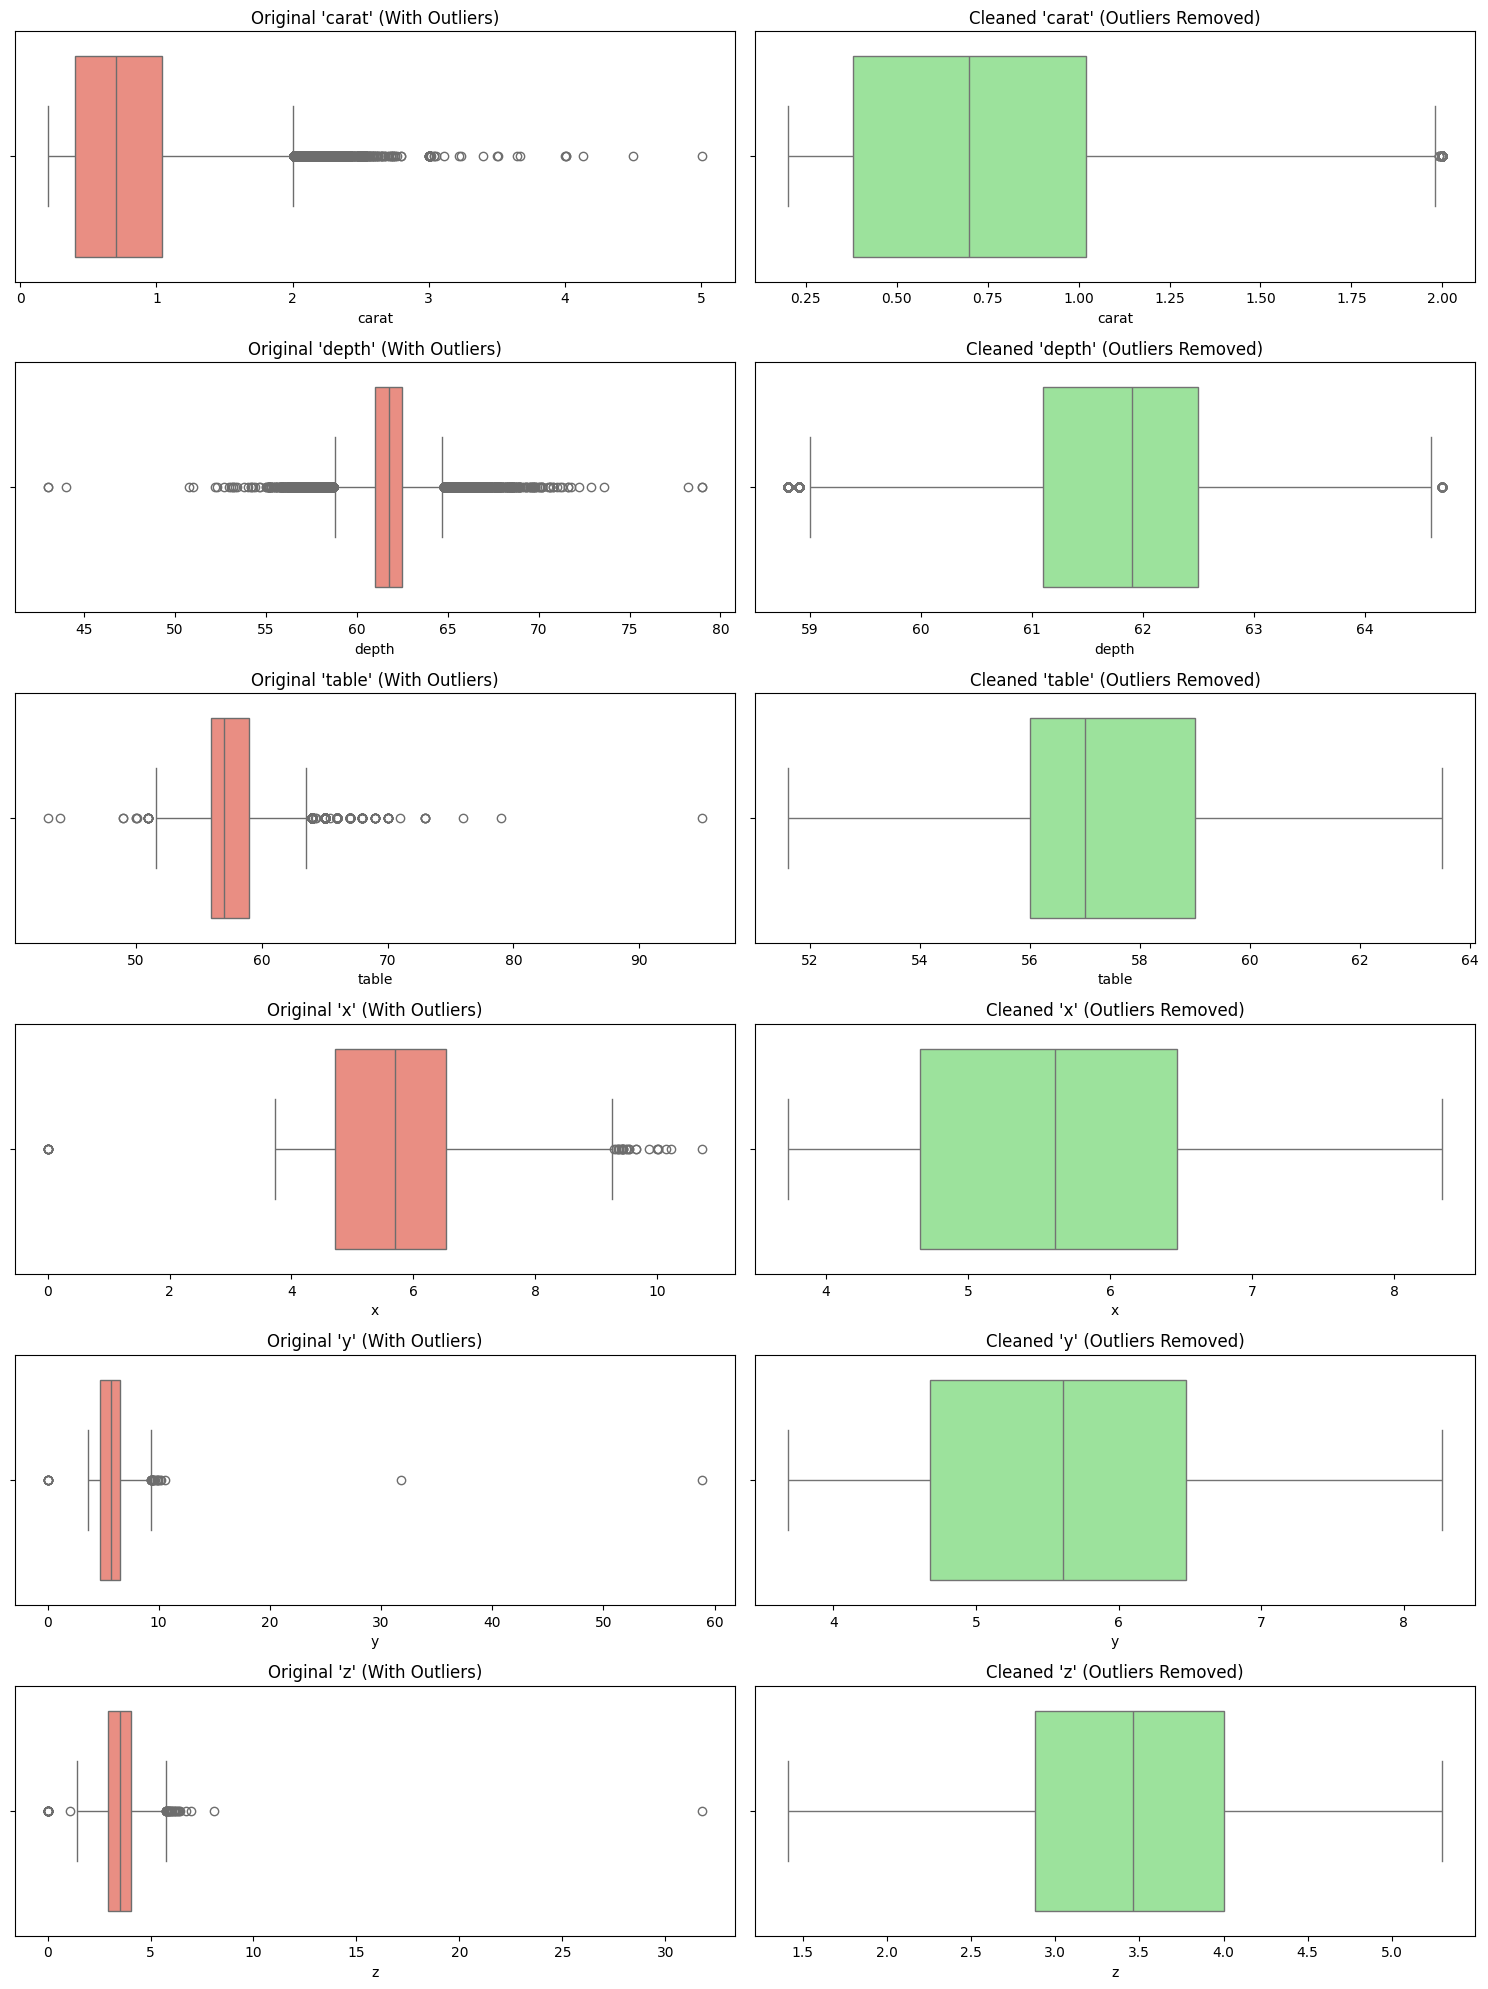

In [4]:
# implementation here

df = df_original.copy()
df_cleaned = df[~((df[numeric_features] < lower_bound) | (df[numeric_features] > upper_bound)).any(axis=1)]

df_cleaned = df_cleaned.reset_index(drop=True)

print(f"Original Data Count    : {df_original.shape[0]}")
print(f"Cleaned Data Count     : {df_cleaned.shape[0]}")
print(f"Removed Outliers Count : {df_original.shape[0] - df_cleaned.shape[0]}")
print("-" * 30)

plt.figure(figsize=(15, 20))

for i, col in enumerate(numeric_features):
    plt.subplot(len(numeric_features), 2, 2*i + 1)
    sns.boxplot(x=df_original[col], color='salmon')
    plt.title(f"Original '{col}' (With Outliers)")
    
    plt.subplot(len(numeric_features), 2, 2*i + 2)
    sns.boxplot(x=df_cleaned[col], color='lightgreen')
    plt.title(f"Cleaned '{col}' (Outliers Removed)")

plt.tight_layout()
plt.show()

## 1.4. Encode the Ordinal Features with Ordinal Encoding (2 Pts)

In [5]:
# implementation here

cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

def safe_map(df, col_name, mapping):
    if df[col_name].dtype == 'object':
        df[col_name] = df[col_name].map(mapping)

safe_map(df_original, 'cut', cut_map)
safe_map(df_original, 'color', color_map)
safe_map(df_original, 'clarity', clarity_map)

safe_map(df_cleaned, 'cut', cut_map)
safe_map(df_cleaned, 'color', color_map)
safe_map(df_cleaned, 'clarity', clarity_map)

## 1.5. Manually shuffle the dataset and split it into training (70%) and testing (30%) sets. Write your own code for shuffling and splitting, avoiding the use of pre-defined functions like train_test_split. (8 Pts)

* ***You  cannot use scikit-learn's shuffle.***

In [6]:
# implementation here

def manual_train_test_split(df, target_col, test_size=0.3, random_seed=42):

    np.random.seed(random_seed)
    
    df_shuffled = df.copy()

    indices = np.arange(len(df_shuffled))
    np.random.shuffle(indices)
    
    split_idx = int(len(df_shuffled) * (1 - test_size))
    
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    train_df = df_shuffled.iloc[train_indices]
    test_df = df_shuffled.iloc[test_indices]
    
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]
    
    return X_train, X_test, y_train, y_test

X_train_original, X_test_original, y_train_original, y_test_original = manual_train_test_split(df_original, 'price')
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = manual_train_test_split(df_cleaned, 'price')

print("--- Manual Split Results (Original Data) ---")
print(f"Train Set Size: {X_train_original.shape}")
print(f"Test Set Size : {X_test_original.shape}")
print(f"Ratio Check (Test %) : {len(X_test_original) / (len(X_train_original) + len(X_test_original)):.2f}")

print("\n--- Manual Split Results (Cleaned Data) ---")
print(f"Train Set Size: {X_train_cleaned.shape}")
print(f"Test Set Size : {X_test_cleaned.shape}")
print(f"Ratio Check (Test %) : {len(X_test_cleaned) / (len(X_train_cleaned) + len(X_test_cleaned)):.2f}")

--- Manual Split Results (Original Data) ---
Train Set Size: (37758, 9)
Test Set Size : (16182, 9)
Ratio Check (Test %) : 0.30

--- Manual Split Results (Cleaned Data) ---
Train Set Size: (34512, 9)
Test Set Size : (14792, 9)
Ratio Check (Test %) : 0.30


# **PART- 2: REGRESSION (50 Pts)**
* Target value: price
* Predictors: The rest

* ***You can use scikit-learn***




In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## 2.1. Linear Regression (15 Pts)
* For each version of the dataset (original, outlier removal) do the following steps:
    * Split the data into train and test sets
    * Fit a linear regression model to train data.
    * Predict the test set and calculate the MSE value.
* Perform a comparison between the regression performance on the original dataset and the dataset after outlier removal. Analyze and interpret the results, discussing how outlier removal affects model accuracy and generalization.

In [8]:
# implementation here
model_original = LinearRegression()
model_cleaned = LinearRegression()

model_original.fit(X_train_original, y_train_original)
model_original_predict = model_original.predict(X_test_original)
mse_original_lr = mean_squared_error(y_test_original, model_original_predict)

print(f"Original Data MSE: {mse_original_lr:.2f}")
print(f"Original Data R2 : {r2_score(y_test_original, model_original_predict):.4f}")

model_cleaned.fit(X_train_cleaned, y_train_cleaned)
model_cleaned_predict = model_cleaned.predict(X_test_cleaned)
mse_cleaned_lr = mean_squared_error(y_test_cleaned, model_cleaned_predict)

print(f"Cleaned Data MSE: {mse_cleaned_lr:.2f}")
print(f"Cleaned Data R2 : {r2_score(y_test_cleaned, model_cleaned_predict):.4f}")

print(f"{mse_original_lr - mse_cleaned_lr:.2f}")

Original Data MSE: 1447689.94
Original Data R2 : 0.9100
Cleaned Data MSE: 1172517.94
Cleaned Data R2 : 0.9041
275171.99


Comparing the results, removing outliers significantly reduced the MSE (from ~1.44M to ~1.17M), meaning the model makes smaller errors on average. However, the R² score dropped slightly from 0.91 to 0.90. This happened because removing outliers reduced the total variance in the dataset. Even though the R² is slightly lower, the lower MSE shows that the cleaned model is actually more reliable and precise in its predictions.

## 2.2. Cross Validation on Linear Regression (10 Pts)
Apply K-Fold Cross Validation on the Linear Regression model using both the original dataset and the outlier-removed dataset. Based on the cross-validation results (mean and standard deviation of R² and RMSE), explain what the metrics demonstrate about the stability and generalization ability of the model.

In [9]:
# implementation here
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_r2_orig = cross_val_score(LinearRegression(), X_train_original, y_train_original, cv=kf, scoring='r2')
cv_mse_orig = cross_val_score(LinearRegression(), X_train_original, y_train_original, cv=kf, scoring='neg_mean_squared_error')
cv_rmse_orig = np.sqrt(-cv_mse_orig)

print("--- Cross-Validation Results (Original Data) ---")
print(f"Average R2   : {cv_r2_orig.mean():.4f} (Std: {cv_r2_orig.std():.4f})")
print(f"Average RMSE : {cv_rmse_orig.mean():.4f} (Std: {cv_rmse_orig.std():.4f})")

cv_r2_clean = cross_val_score(LinearRegression(), X_train_cleaned, y_train_cleaned, cv=kf, scoring='r2')
cv_mse_clean = cross_val_score(LinearRegression(), X_train_cleaned, y_train_cleaned, cv=kf, scoring='neg_mean_squared_error')
cv_rmse_clean = np.sqrt(-cv_mse_clean)

print("\n--- Cross-Validation Results (Cleaned Data) ---")
print(f"Average R2   : {cv_r2_clean.mean():.4f} (Std: {cv_r2_clean.std():.4f})")
print(f"Average RMSE : {cv_rmse_clean.mean():.4f} (Std: {cv_rmse_clean.std():.4f})")

--- Cross-Validation Results (Original Data) ---
Average R2   : 0.9054 (Std: 0.0062)
Average RMSE : 1223.2180 (Std: 50.8509)

--- Cross-Validation Results (Cleaned Data) ---
Average R2   : 0.9068 (Std: 0.0016)
Average RMSE : 1038.1125 (Std: 20.7657)


The cross-validation results show that the model became much more stable after removing outliers. The Standard Deviation (Std) of the RMSE dropped significantly (from 50.8 to 20.7), which means the model gives consistent results. Also, the improved R² score shows that the model generalizes better to new data.

## 2.3. kNN Regression (15 Pts)
* For each version of the dataset (original, outlier-removed), execute the following steps:
    * Split the data into train and test sets
    * Create an instance of kNN with a number of neighbors between 1-10, then fit kNN regression model to train data.
    * Predict the test set and calculate the MSE value for each k.
    * Plot the MSE vs k curve to decide on the optimal k.
    * Report the R-squared value for the optimal k.
* Compare the MSE values for each dataset and comment on the results. Which dataset gives the best result? Why do you think that is?
* After identifying the dataset and k value that gives the best performance, apply feature scaling (e.g., StandardScaler) to that dataset only. Repeat the kNN regression steps with scaled data and analyze how scaling changes the results compared to the non-scaled version.

1. ORIGINAL DATASET


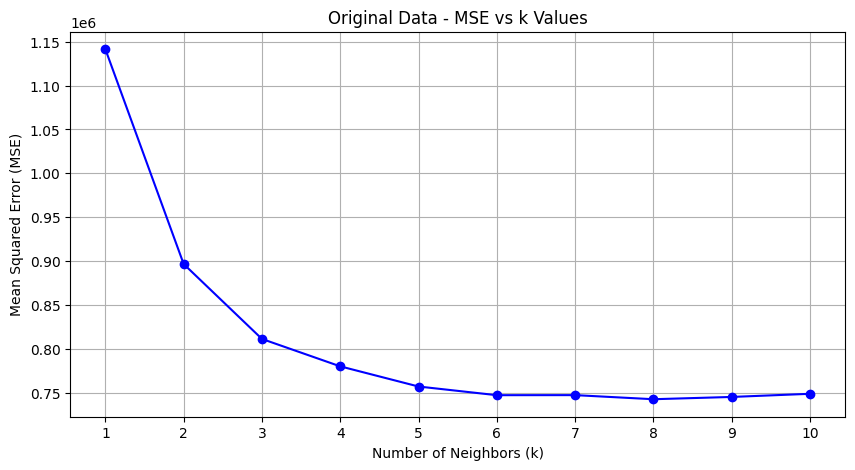

--- Original Data Results ---
Optimal k value : 8
Minimum MSE     : 742540.23
R2 Score        : 0.9539
------------------------------

2. CLEANED DATASET


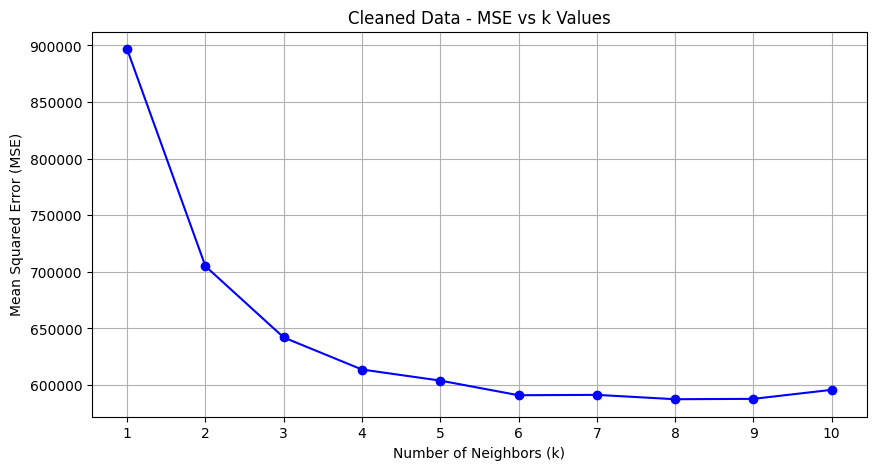

--- Cleaned Data Results ---
Optimal k value : 8
Minimum MSE     : 587461.43
R2 Score        : 0.9519
------------------------------

COMMENT: The cleaned dataset performed better, reducing the MSE by 155078.80.

3. ANALYSIS WITH SCALED DATA


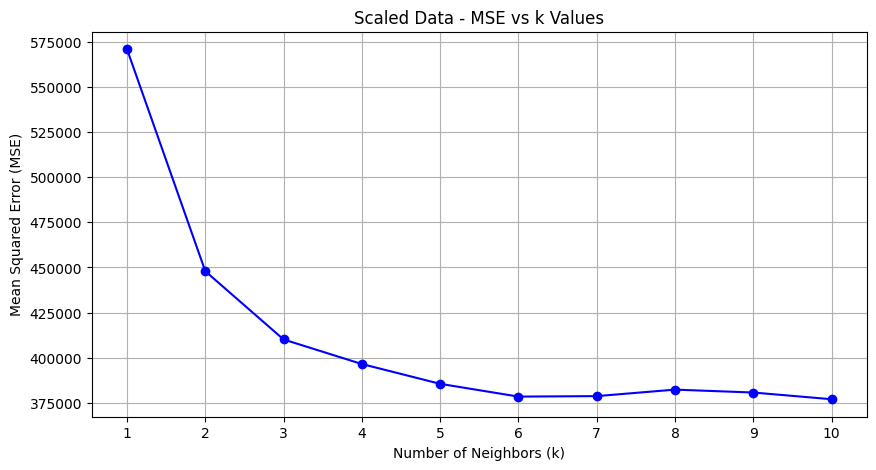

--- Scaled Data Results ---
Optimal k value : 10
Minimum MSE     : 376918.78
R2 Score        : 0.9692
------------------------------

RESULT: Scaling reduced the MSE on the Cleaned dataset from 587461.43 to 376918.78.


In [10]:
# implementation here
def evaluate_knn(X_train, X_test, y_train, y_test, dataset_name):
    mse_values = []
    r2_values = []
    k_range = range(1, 11)

    for k in k_range:
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        mse_values.append(mse)
        r2_values.append(r2)

    best_k_index = np.argmin(mse_values)
    best_k = k_range[best_k_index]
    best_mse = mse_values[best_k_index]
    best_r2 = r2_values[best_k_index]

    plt.figure(figsize=(10, 5))
    plt.plot(k_range, mse_values, marker='o', linestyle='-', color='b')
    plt.title(f'{dataset_name} - MSE vs k Values') 
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()

    print(f"--- {dataset_name} Results ---")
    print(f"Optimal k value : {best_k}")
    print(f"Minimum MSE     : {best_mse:.2f}")
    print(f"R2 Score        : {best_r2:.4f}")
    print("-" * 30)
    
    return best_mse, best_k, best_r2

print("1. ORIGINAL DATASET")
mse_original, k_original, r2_original = evaluate_knn(X_train_original, X_test_original, y_train_original, y_test_original, "Original Data")

print("\n2. CLEANED DATASET")
mse_cleaned, k_cleaned, r2_cleaned = evaluate_knn(X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned, "Cleaned Data")

if mse_cleaned < mse_original:
    print(f"\nCOMMENT: The cleaned dataset performed better, reducing the MSE by {mse_original - mse_cleaned:.2f}.")
    best_X_train = X_train_cleaned
    best_X_test = X_test_cleaned
    best_y_train = y_train_cleaned
    best_y_test = y_test_cleaned
    dataset_choice = "Cleaned" 
else:
    print(f"\nCOMMENT: The original dataset performed better.")
    best_X_train = X_train_original
    best_X_test = X_test_original
    best_y_train = y_train_original
    best_y_test = y_test_original
    dataset_choice = "Original"

print("\n3. ANALYSIS WITH SCALED DATA")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(best_X_train)
X_test_scaled = scaler.transform(best_X_test)
mse_scaled, k_scaled, r2_scaled = evaluate_knn(X_train_scaled, X_test_scaled, best_y_train, best_y_test, "Scaled Data")

print(f"\nRESULT: Scaling reduced the MSE on the {dataset_choice} dataset from {min(mse_original, mse_cleaned):.2f} to {mse_scaled:.2f}.")

The dataset with Scaling and Outlier Removal gave the best result with the lowest MSE. I observed that for the non-scaled datasets, the optimal k value was 8, but for the scaled dataset, the best k increased to 10. Scaling was the most critical step because without it, features with large values dominate the distance formula; scaling balanced the features and significantly improved the model's accuracy.

## 2.4. Compare the Regression Methods (10 Pts)

* Compare and contrast the performance of kNN and Linear Regression models across the different dataset versions.

* Discuss the strengths and limitations of each model based on your results

In [11]:
# implementation here
comparison_data = []

comparison_data.append({
    'Model': 'Linear Regression',
    'Dataset': 'Original',
    'Scaling': 'None',
    'MSE': mse_original_lr,
    'R2 Score': r2_score(y_test_original, model_original_predict)
})

comparison_data.append({
    'Model': 'Linear Regression',
    'Dataset': 'Cleaned (No Outliers)',
    'Scaling': 'None',
    'MSE': mse_cleaned_lr,
    'R2 Score': r2_score(y_test_cleaned, model_cleaned_predict)
})

comparison_data.append({
    'Model': 'kNN Regression',
    'Dataset': 'Original',
    'Scaling': 'None',
    'MSE': mse_original,
    'R2 Score': r2_original
})

comparison_data.append({
    'Model': 'kNN Regression',
    'Dataset': 'Cleaned (No Outliers)',
    'Scaling': 'None',
    'MSE': mse_cleaned,
    'R2 Score': r2_cleaned
})

comparison_data.append({
    'Model': 'kNN Regression',
    'Dataset': 'Cleaned (No Outliers)',
    'Scaling': 'StandardScaler',
    'MSE': mse_scaled,
    'R2 Score': r2_scaled
})

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values(by='MSE', ascending=True).reset_index(drop=True)

print("--- FINAL PERFORMANCE COMPARISON ---")
display(df_comparison)

--- FINAL PERFORMANCE COMPARISON ---


,Model,Dataset,Scaling,MSE,R2 Score
0,kNN Regression,Cleaned (No Outliers),StandardScaler,3.769188e+05,0.969167
1,kNN Regression,Cleaned (No Outliers),None,5.874614e+05,0.951944
2,kNN Regression,Original,None,7.425402e+05,0.953859
3,Linear Regression,Cleaned (No Outliers),None,1.172518e+06,0.904086
4,Linear Regression,Original,None,1.447690e+06,0.910041


Comparing the models, kNN Regression performed much better than Linear Regression. kNN achieved a much lower MSE (~376k vs ~1.17M). This suggests that the data has complex, non-linear patterns that Linear Regression couldn't capture, but kNN handled them well.

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw3.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.